Full Transformers and Multi-Head Attention Practice

Goal:
- build a small trainable transformer
- train it on a toy next-token task
- understand transformer inputs, outputs, and loss
- generate tokens autoregressively
- visualize attention after training

In [2]:
import math
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("Pytorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)

Pytorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


# Create synthetic sequences

Each sequence will be a simple counting pattern modulo vocab_size.

In [3]:
def generate_counting_data(num_sequences=1000, seq_len=8, vocab_size=20):
  data = []

  for _ in range(num_sequences):
    start = random.randint(0, vocab_size - 1)
    seq =[(start+i)% vocab_size for i in range(seq_len +1)]
    data.append(seq)

  return torch.tensor(data, dtype=torch.long)



In [6]:
data = generate_counting_data(num_sequences=10, seq_len=8, vocab_size=20)

print(data.shape)
print(data[:])

torch.Size([10, 9])
tensor([[ 2,  3,  4,  5,  6,  7,  8,  9, 10],
        [17, 18, 19,  0,  1,  2,  3,  4,  5],
        [ 8,  9, 10, 11, 12, 13, 14, 15, 16],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17],
        [ 7,  8,  9, 10, 11, 12, 13, 14, 15],
        [16, 17, 18, 19,  0,  1,  2,  3,  4],
        [ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [11, 12, 13, 14, 15, 16, 17, 18, 19],
        [ 5,  6,  7,  8,  9, 10, 11, 12, 13]])


Split into inputs and targets

If full sequence length is 9:
- input gets first 8 tokens
- target gets next 8 tokens

In [7]:
inputs = data[:, :-1]
targets = data[:, 1:]

print("inputs shape:", inputs.shape)
print("targets shape:", targets.shape)

print("example input :", inputs[0])
print("example target:", targets[0])


inputs shape: torch.Size([10, 8])
targets shape: torch.Size([10, 8])
example input : tensor([2, 3, 4, 5, 6, 7, 8, 9])
example target: tensor([ 3,  4,  5,  6,  7,  8,  9, 10])


Train / validation split
Production habit:
separate train and validation data.

In [8]:
full_data = generate_counting_data(num_sequences=2000, seq_len=8, vocab_size=20)

train_data = full_data[:1600]
val_data = full_data[1600:]

train_inputs = train_data[:, :-1]
train_targets = train_data[:, 1:]

val_inputs = val_data[:, :-1]
val_targets = val_data[:, 1:]

print("train inputs shape:", train_inputs.shape)
print("val inputs shape:", val_inputs.shape)

train inputs shape: torch.Size([1600, 8])
val inputs shape: torch.Size([400, 8])


Batch sampling helper

In [9]:
def get_batch(inputs, targets, batch_size=32):
    indices = torch.randint(0, inputs.shape[0], (batch_size,))
    x = inputs[indices]
    y = targets[indices]
    return x, y

In [10]:
xb, yb = get_batch(train_inputs, train_targets, batch_size=4)

print("xb shape:", xb.shape)
print("yb shape:", yb.shape)
print(xb)
print(yb)

xb shape: torch.Size([4, 8])
yb shape: torch.Size([4, 8])
tensor([[17, 18, 19,  0,  1,  2,  3,  4],
        [ 1,  2,  3,  4,  5,  6,  7,  8],
        [17, 18, 19,  0,  1,  2,  3,  4],
        [ 9, 10, 11, 12, 13, 14, 15, 16]])
tensor([[18, 19,  0,  1,  2,  3,  4,  5],
        [ 2,  3,  4,  5,  6,  7,  8,  9],
        [18, 19,  0,  1,  2,  3,  4,  5],
        [10, 11, 12, 13, 14, 15, 16, 17]])


Token + positional embeddings

In [11]:
class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, max_len, d_model):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)

    def forward(self, token_ids):
        B, T = token_ids.shape
        positions = torch.arange(T, device=token_ids.device).unsqueeze(0).expand(B, T)

        token_vectors = self.token_embed(token_ids)
        pos_vectors = self.pos_embed(positions)

        return token_vectors + pos_vectors

Multi-head masked self-attention

In [12]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, causal=True):
        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        if causal:
            mask = torch.tril(torch.ones(T, T, device=x.device))
            scores = scores.masked_fill(mask == 0, float("-inf"))

        weights = torch.softmax(scores, dim=-1)

        out = weights @ V
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        out = self.out_proj(out)

        return out, weights

Feed-forward network

In [13]:
class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, d_model)
        )

    def forward(self, x):
        return self.net(x)

Transformer block

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, hidden_dim):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, hidden_dim)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, causal=True):
        attn_out, weights = self.attn(x, causal=causal)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        return x, weights

Full tiny transformer language model

In [15]:
class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, num_heads, hidden_dim, num_layers):
        super().__init__()

        self.embed = TokenAndPositionEmbedding(vocab_size, max_len, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, hidden_dim)
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids, causal=True):
        x = self.embed(token_ids)

        all_weights = []

        for block in self.blocks:
            x, weights = block(x, causal=causal)
            all_weights.append(weights)

        logits = self.lm_head(x)
        return logits, all_weights

In [16]:
model = TinyTransformerLM(
    vocab_size=20,
    max_len=8,
    d_model=32,
    num_heads=4,
    hidden_dim=64,
    num_layers=2
).to(device)

print(model)

TinyTransformerLM(
  (embed): TokenAndPositionEmbedding(
    (token_embed): Embedding(20, 32)
    (pos_embed): Embedding(8, 32)
  )
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (Wq): Linear(in_features=32, out_features=32, bias=True)
        (Wk): Linear(in_features=32, out_features=32, bias=True)
        (Wv): Linear(in_features=32, out_features=32, bias=True)
        (out_proj): Linear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=32, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=32, bias=True)
        )
      )
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=32, out_features=20, bias=True)
)


In [17]:
xb, yb = get_batch(train_inputs, train_targets, batch_size=4)
xb = xb.to(device)
yb = yb.to(device)

logits, all_weights = model(xb)

print("input shape:", xb.shape)
print("target shape:", yb.shape)
print("logits shape:", logits.shape)
print("number of attention weight sets:", len(all_weights))
print("one attention weight shape:", all_weights[0].shape)

input shape: torch.Size([4, 8])
target shape: torch.Size([4, 8])
logits shape: torch.Size([4, 8, 20])
number of attention weight sets: 2
one attention weight shape: torch.Size([4, 4, 8, 8])


Connect logits to CrossEntropyLoss

CrossEntropyLoss expects:
- predictions of shape (N, C)
- targets of shape (N)

But transformer logits are:
(B, T, vocab_size)

So we flatten them.

In [18]:
B, T, V = logits.shape

logits_flat = logits.view(B * T, V)
targets_flat = yb.view(B * T)

print("logits_flat shape:", logits_flat.shape)
print("targets_flat shape:", targets_flat.shape)

logits_flat shape: torch.Size([32, 20])
targets_flat shape: torch.Size([32])


In [19]:
criterion = nn.CrossEntropyLoss()
loss = criterion(logits_flat, targets_flat)

print("loss:", loss.item())

loss: 3.1493167877197266


In [20]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

logits, all_weights = model(xb)
B, T, V = logits.shape

loss = criterion(logits.view(B * T, V), yb.view(B * T))

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("training step complete")
print("loss:", loss.item())

training step complete
loss: 3.1493167877197266


Evaluation helper
Production habit:
write a separate evaluation function.

In [21]:
def evaluate_loss(model, inputs, targets, batch_size=64, num_batches=20):
    model.eval()
    losses = []

    with torch.no_grad():
        for _ in range(num_batches):
            xb, yb = get_batch(inputs, targets, batch_size=batch_size)
            xb = xb.to(device)
            yb = yb.to(device)

            logits, _ = model(xb)
            B, T, V = logits.shape

            loss = criterion(logits.view(B * T, V), yb.view(B * T))
            losses.append(loss.item())

    model.train()
    return sum(losses) / len(losses)

Full training loop

In [22]:
model = TinyTransformerLM(
    vocab_size=20,
    max_len=8,
    d_model=32,
    num_heads=4,
    hidden_dim=64,
    num_layers=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [23]:
train_losses = []
val_losses = []

num_steps = 500

for step in range(num_steps):
    xb, yb = get_batch(train_inputs, train_targets, batch_size=64)
    xb = xb.to(device)
    yb = yb.to(device)

    logits, _ = model(xb)
    B, T, V = logits.shape

    loss = criterion(logits.view(B * T, V), yb.view(B * T))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 25 == 0:
        train_loss = evaluate_loss(model, train_inputs, train_targets)
        val_loss = evaluate_loss(model, val_inputs, val_targets)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Step {step:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Step 000 | Train Loss: 3.1404 | Val Loss: 3.1486
Step 025 | Train Loss: 1.7994 | Val Loss: 1.8133
Step 050 | Train Loss: 0.7853 | Val Loss: 0.7879
Step 075 | Train Loss: 0.3378 | Val Loss: 0.3385
Step 100 | Train Loss: 0.1764 | Val Loss: 0.1765
Step 125 | Train Loss: 0.1099 | Val Loss: 0.1104
Step 150 | Train Loss: 0.0766 | Val Loss: 0.0769
Step 175 | Train Loss: 0.0572 | Val Loss: 0.0573
Step 200 | Train Loss: 0.0446 | Val Loss: 0.0447
Step 225 | Train Loss: 0.0360 | Val Loss: 0.0360
Step 250 | Train Loss: 0.0297 | Val Loss: 0.0297
Step 275 | Train Loss: 0.0250 | Val Loss: 0.0250
Step 300 | Train Loss: 0.0214 | Val Loss: 0.0214
Step 325 | Train Loss: 0.0185 | Val Loss: 0.0185
Step 350 | Train Loss: 0.0162 | Val Loss: 0.0162
Step 375 | Train Loss: 0.0143 | Val Loss: 0.0143
Step 400 | Train Loss: 0.0127 | Val Loss: 0.0128
Step 425 | Train Loss: 0.0114 | Val Loss: 0.0114
Step 450 | Train Loss: 0.0103 | Val Loss: 0.0103
Step 475 | Train Loss: 0.0093 | Val Loss: 0.0094


Plot training and validation loss

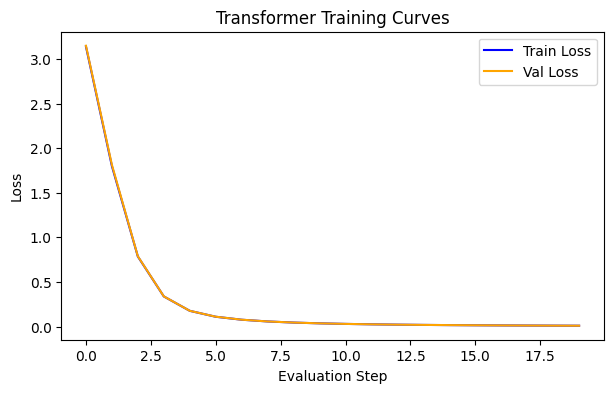

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train Loss", color= "blue")
plt.plot(val_losses, label="Val Loss", color="orange")
plt.legend()
plt.title("Transformer Training Curves")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.show()

Check predictions on a batch

In [26]:
model.eval()

xb, yb = get_batch(val_inputs, val_targets, batch_size=4)
xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    logits, all_weights = model(xb)
    preds = torch.argmax(logits, dim=-1)

print("inputs:")
print(xb.cpu())

print("\ntargets:")
print(yb.cpu())

print("\npredictions:")
print(preds.cpu())

inputs:
tensor([[ 3,  4,  5,  6,  7,  8,  9, 10],
        [ 2,  3,  4,  5,  6,  7,  8,  9],
        [17, 18, 19,  0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9, 10, 11, 12]])

targets:
tensor([[ 4,  5,  6,  7,  8,  9, 10, 11],
        [ 3,  4,  5,  6,  7,  8,  9, 10],
        [18, 19,  0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11, 12, 13]])

predictions:
tensor([[ 4,  5,  6,  7,  8,  9, 10, 11],
        [ 3,  4,  5,  6,  7,  8,  9, 10],
        [18, 19,  0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11, 12, 13]])


Attention visualization after training


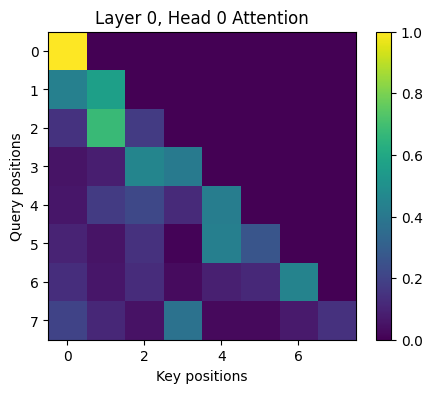

In [27]:
layer0_head0 = all_weights[0][0, 0].detach().cpu().numpy()

plt.figure(figsize=(5, 4))
plt.imshow(layer0_head0, cmap="viridis")
plt.colorbar()
plt.title("Layer 0, Head 0 Attention")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

Compare multiple heads in the same layer

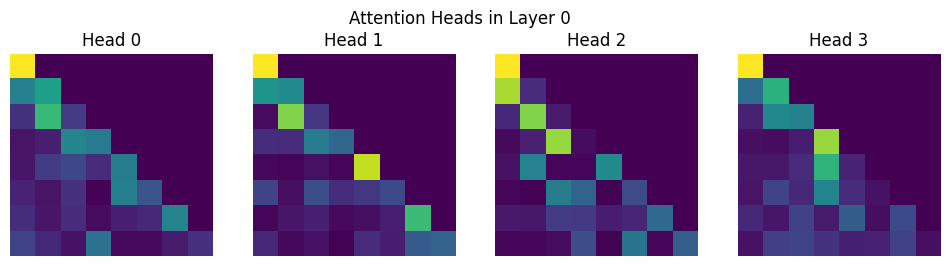

In [28]:
weights_layer0 = all_weights[0][0].detach().cpu()

num_heads = weights_layer0.shape[0]

plt.figure(figsize=(12, 3))

for h in range(num_heads):
    plt.subplot(1, num_heads, h + 1)
    plt.imshow(weights_layer0[h].numpy(), cmap="viridis")
    plt.title(f"Head {h}")
    plt.axis("off")

plt.suptitle("Attention Heads in Layer 0")
plt.show()

3D attention visualization

In [29]:
from mpl_toolkits.mplot3d import Axes3D

In [30]:
attn_matrix = all_weights[0][0, 0].detach().cpu().numpy()
T = attn_matrix.shape[0]

x_coords = []
y_coords = []
z_coords = []

for i in range(T):
    for j in range(T):
        x_coords.append(i)
        y_coords.append(j)
        z_coords.append(attn_matrix[i, j])

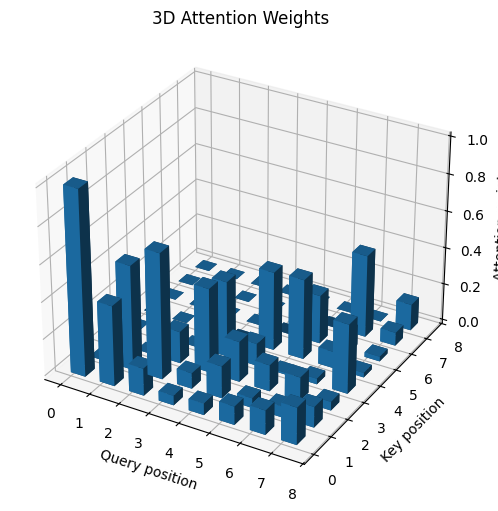

In [31]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(
    x_coords,
    y_coords,
    [0] * len(z_coords),
    0.5,
    0.5,
    z_coords
)

ax.set_xlabel("Query position")
ax.set_ylabel("Key position")
ax.set_zlabel("Attention weight")
ax.set_title("3D Attention Weights")
plt.show()

Autoregressive generation

Now we let the model generate tokens one step at a time.

In [32]:
def generate(model, start_tokens, max_new_tokens):
    model.eval()

    tokens = start_tokens.clone().to(device)

    for _ in range(max_new_tokens):
        current_input = tokens[:, -8:]

        with torch.no_grad():
            logits, _ = model(current_input, causal=True)

        next_token_logits = logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

        tokens = torch.cat([tokens, next_token], dim=1)

    return tokens

In [33]:
start = torch.tensor([[3, 4, 5]], dtype=torch.long)
generated = generate(model, start, max_new_tokens=5)

print("start:", start)
print("generated:", generated.cpu())

start: tensor([[3, 4, 5]])
generated: tensor([[ 3,  4,  5,  6,  7,  8,  9, 10]])


Compare expected pattern

Since training data followed a counting rule,
the model should learn to continue counting modulo vocab_size.


In [34]:
start = torch.tensor([[17, 18, 19]], dtype=torch.long)
generated = generate(model, start, max_new_tokens=5)

print("start:", start)
print("generated:", generated.cpu())

start: tensor([[17, 18, 19]])
generated: tensor([[17, 18, 19,  0,  1,  2,  3,  4]])


Production habit: config dictionary
Instead of scattering magic numbers everywhere.

In [35]:
config = {
    "vocab_size": 20,
    "max_len": 8,
    "d_model": 32,
    "num_heads": 4,
    "hidden_dim": 64,
    "num_layers": 2,
    "learning_rate": 0.001,
    "batch_size": 64,
    "num_steps": 300
}

print(config)

{'vocab_size': 20, 'max_len': 8, 'd_model': 32, 'num_heads': 4, 'hidden_dim': 64, 'num_layers': 2, 'learning_rate': 0.001, 'batch_size': 64, 'num_steps': 300}


Build model from config

In [36]:
model_cfg = TinyTransformerLM(
    vocab_size=config["vocab_size"],
    max_len=config["max_len"],
    d_model=config["d_model"],
    num_heads=config["num_heads"],
    hidden_dim=config["hidden_dim"],
    num_layers=config["num_layers"]
).to(device)

print(model_cfg)

TinyTransformerLM(
  (embed): TokenAndPositionEmbedding(
    (token_embed): Embedding(20, 32)
    (pos_embed): Embedding(8, 32)
  )
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (Wq): Linear(in_features=32, out_features=32, bias=True)
        (Wk): Linear(in_features=32, out_features=32, bias=True)
        (Wv): Linear(in_features=32, out_features=32, bias=True)
        (out_proj): Linear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=32, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=32, bias=True)
        )
      )
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=32, out_features=20, bias=True)
)


Count parameters
Production habit:
know model size.

In [37]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("total params:", total_params)
print("trainable params:", trainable_params)

total params: 18644
trainable params: 18644


Save model weights

In [38]:
torch.save(model.state_dict(), "tiny_transformer_lm.pth")
print("model saved")

model saved


Gradient norm inspection
Production habit:
inspect gradient sizes when training behaves strangely.

In [39]:
xb, yb = get_batch(train_inputs, train_targets, batch_size=32)
xb = xb.to(device)
yb = yb.to(device)

logits, _ = model(xb)
B, T, V = logits.shape
loss = criterion(logits.view(B * T, V), yb.view(B * T))

optimizer.zero_grad()
loss.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, "grad norm =", param.grad.norm().item())

embed.token_embed.weight grad norm = 0.00016790379595477134
embed.pos_embed.weight grad norm = 0.00019323146261740476
blocks.0.attn.Wq.weight grad norm = 0.00015759409870952368
blocks.0.attn.Wq.bias grad norm = 1.8452336007612757e-05
blocks.0.attn.Wk.weight grad norm = 0.00016650302859488875
blocks.0.attn.Wk.bias grad norm = 5.295720459375097e-12
blocks.0.attn.Wv.weight grad norm = 0.0005043325945734978
blocks.0.attn.Wv.bias grad norm = 0.0001012319844448939
blocks.0.attn.out_proj.weight grad norm = 0.0006588513497263193
blocks.0.attn.out_proj.bias grad norm = 0.0001559961965540424
blocks.0.norm1.weight grad norm = 0.0001617723173694685
blocks.0.norm1.bias grad norm = 0.00020104342547710985
blocks.0.ffn.net.0.weight grad norm = 0.0005626445054076612
blocks.0.ffn.net.0.bias grad norm = 0.00013544809189625084
blocks.0.ffn.net.2.weight grad norm = 0.0008773367153480649
blocks.0.ffn.net.2.bias grad norm = 0.00016789676737971604
blocks.0.norm2.weight grad norm = 0.00013964872050564736
block